In [54]:
import sys
print(sys.executable)

!{sys.executable} -m pip install pandas numpy pyarrow scikit-learn torch

c:\Users\uvvss\Downloads\ro-power-optimization\.venv311\Scripts\python.exe



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [55]:
import pandas as pd
import numpy as np

print("Pandas OK:", pd.__version__)

Pandas OK: 2.1.4


In [56]:
%pip install pandas numpy pyarrow scikit-learn scipy torch matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [57]:
from __future__ import annotations

import random
import math
from dataclasses import dataclass
from typing import Dict, Optional, Tuple, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from scipy.optimize import Bounds, LinearConstraint, minimize
from scipy.spatial import ConvexHull, QhullError

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

In [58]:
import sys
print(sys.executable)

import torch
print(torch.__version__)
print("Torch OK")

c:\Users\uvvss\Downloads\ro-power-optimization\.venv311\Scripts\python.exe
2.10.0+cpu
Torch OK


In [59]:
@dataclass
class RLConfig:
    control_dt_hours: float = 1.0
    episode_hours: int = 168          # 1 week
    price_lookahead_hours: int = 24

    polynomial_degree: int = 3
    random_state: int = 42

    total_steps: int = 3000
    start_steps: int = 500
    update_after: int = 500
    update_every: int = 20
    batch_size: int = 256
    replay_size: int = 200000

    gamma: float = 0.99
    tau: float = 0.005
    policy_lr: float = 3e-4
    q_lr: float = 3e-4
    alpha_lr: float = 3e-4
    hidden_size: int = 256
    device: str = "cpu"

    lambda_cost: float = 1.0
    lambda_backlog: float = 10.0
    lambda_smooth: float = 0.20
    lambda_rl_track: float = 0.10
    lambda_violation: float = 25.0
    max_action_change_gpm: float = 0.75

    recovery_low: float = 0.48
    recovery_high: float = 0.82

    bounds_padding_fraction: float = 0.05


cfg = RLConfig()
DEVICE = torch.device(cfg.device)

random.seed(cfg.random_state)
np.random.seed(cfg.random_state)
torch.manual_seed(cfg.random_state)

print("Device:", DEVICE)

Device: cpu


In [60]:
TIMESTAMP_COL = "Timestamp"

POWER_COL = "RO Power Consumption (W)"
PERM_EC_COL = "RO Overall Permeate EC (uS/cm)"
TEMP_COL = "Temperature (C)"
FEED_EC_COL = "RO Feed EC (uS/cm)"

Q_PERM_COL = "RO Overall Permeate Flowrate (gpm)"
Q_CONC_COL = "RO Overall Concentrate Flowrate (gpm)"
Q_RECIRC_COL = "RO Recirculation Flow Rate (gpm)"

FLOW_COLUMNS = [
    Q_PERM_COL,
    Q_CONC_COL,
    Q_RECIRC_COL,
]

COMMON_FEATURES = [
    TEMP_COL,
    FEED_EC_COL,
    PERM_EC_COL,
    Q_CONC_COL,
    Q_PERM_COL,
    Q_RECIRC_COL,
    POWER_COL,
]

print("Flow columns:", FLOW_COLUMNS)

Flow columns: ['RO Overall Permeate Flowrate (gpm)', 'RO Overall Concentrate Flowrate (gpm)', 'RO Recirculation Flow Rate (gpm)']


In [61]:
constant_10m = pd.read_parquet("../models/constant_10m_clean.parquet")
varied_10m   = pd.read_parquet("../models/varied_10m_clean.parquet")

constant_10m[TIMESTAMP_COL] = pd.to_datetime(constant_10m[TIMESTAMP_COL])
varied_10m[TIMESTAMP_COL] = pd.to_datetime(varied_10m[TIMESTAMP_COL])

print("Constant:", constant_10m.shape)
print("Varied:", varied_10m.shape)
print(constant_10m.columns.tolist())
print(varied_10m.columns.tolist())

Constant: (1908, 13)
Varied: (981, 12)
['Timestamp', 'n_points', 'Temperature (C)', 'RO IN Feedwater Pressure (psi)', 'RO OUT Concentrate Pressure (psi)', 'RO Feed EC (uS/cm)', 'RO Overall Permeate EC (uS/cm)', 'RO Overall Concentrate EC (uS/cm)', 'RO Overall Concentrate Flowrate (gpm)', 'RO Overall Permeate Flowrate (gpm)', 'RO Recirculation Flow Rate (gpm)', 'RO Power Consumption (W)', 'timestamp']
['Timestamp', 'n_points', 'Temperature (C)', 'RO IN Feedwater Pressure (psi)', 'RO OUT Concentrate Pressure (psi)', 'RO Feed EC (uS/cm)', 'RO Overall Permeate EC (uS/cm)', 'RO Overall Concentrate Flowrate (gpm)', 'RO Overall Permeate Flowrate (gpm)', 'RO Recirculation Flow Rate (gpm)', 'RO Power Consumption (W)', 'timestamp']


In [62]:
def resample_hourly(df):
    keep_cols = [TIMESTAMP_COL] + [c for c in COMMON_FEATURES if c in df.columns]
    df = df[keep_cols].copy()
    df = df.dropna(subset=[TIMESTAMP_COL])
    df = df.sort_values(TIMESTAMP_COL)

    hourly = (
        df.set_index(TIMESTAMP_COL)
        .resample("1h")
        .mean(numeric_only=True)
        .dropna(how="all")
        .reset_index()
    )

    hourly = hourly.dropna(subset=FLOW_COLUMNS + [POWER_COL]).reset_index(drop=True)
    return hourly


constant_hourly = resample_hourly(constant_10m)
varied_hourly = resample_hourly(varied_10m)

print("Constant hourly:", constant_hourly.shape)
print("Varied hourly:", varied_hourly.shape)

constant_hourly.head()

Constant hourly: (320, 8)
Varied hourly: (168, 8)


,Timestamp,Temperature (C),RO Feed EC (uS/cm),RO Overall Permeate EC (uS/cm),RO Overall Concentrate Flowrate (gpm),RO Overall Permeate Flowrate (gpm),RO Recirculation Flow Rate (gpm),RO Power Consumption (W)
0,2025-12-04 16:00:00,27.114477,2080.295379,103.101152,0.697756,2.623198,2.003590,1551.002232
1,2025-12-04 17:00:00,27.032298,2101.005027,112.194711,0.698145,2.629192,2.001320,1591.379643
2,2025-12-04 18:00:00,26.905029,2133.925722,113.268903,0.701481,2.628932,1.999936,1607.719758
3,2025-12-04 19:00:00,26.863934,2175.089217,115.959447,0.698547,2.642020,1.999200,1628.153320
4,2025-12-04 20:00:00,26.833334,2219.775541,117.291567,0.700376,2.655527,2.000623,1648.206536


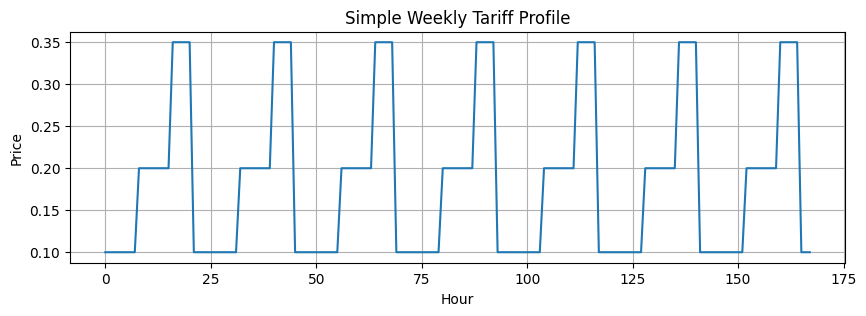

In [63]:
def make_weekly_tariff(episode_hours=168):
    prices = []

    for h in range(episode_hours):
        hour_of_day = h % 24

        if 16 <= hour_of_day < 21:
            price = 0.35   # peak
        elif 8 <= hour_of_day < 16:
            price = 0.20   # mid
        else:
            price = 0.10   # off-peak

        prices.append(price)

    return {
        "simple_tou": np.array(prices, dtype=np.float64)
    }


tariff_profiles = make_weekly_tariff(cfg.episode_hours)

plt.figure(figsize=(10, 3))
plt.plot(tariff_profiles["simple_tou"])
plt.title("Simple Weekly Tariff Profile")
plt.xlabel("Hour")
plt.ylabel("Price")
plt.grid(True)
plt.show()

In [64]:
class PowerSurrogate:
    def __init__(self, degree=3, random_state=42):
        self.pipeline = Pipeline([
            ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
            ("scaler", StandardScaler()),
            ("lasso", LassoCV(cv=5, random_state=random_state, max_iter=50000))
        ])
        self.metrics = {}

    def fit(self, df):
        X = df[FLOW_COLUMNS].to_numpy(dtype=np.float64)
        y = df[POWER_COL].to_numpy(dtype=np.float64)

        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=0.20,
            random_state=42
        )

        self.pipeline.fit(X_train, y_train)
        pred = self.pipeline.predict(X_test)

        self.metrics = {
            "r2": float(r2_score(y_test, pred)),
            "mae": float(mean_absolute_error(y_test, pred)),
            "rmse": float(np.sqrt(mean_squared_error(y_test, pred))),
        }

        print("Power surrogate metrics:")
        print(self.metrics)

    def predict_watts(self, action_gpm):
        arr = np.asarray(action_gpm, dtype=np.float64)
        arr_2d = np.atleast_2d(arr)
        pred = self.pipeline.predict(arr_2d)
        pred = np.maximum(pred, 0.0)

        if arr.ndim == 1:
            return float(pred[0])
        return pred


power_surrogate = PowerSurrogate(
    degree=cfg.polynomial_degree,
    random_state=cfg.random_state
)

power_surrogate.fit(varied_hourly)

Power surrogate metrics:
{'r2': 0.927509626365153, 'mae': 53.685818191532256, 'rmse': 67.03180438143332}


In [65]:
class FeasibleRegion:
    def __init__(self, points, padding_fraction=0.05):
        self.points = np.asarray(points, dtype=np.float64)

        mins = self.points.min(axis=0)
        maxs = self.points.max(axis=0)
        span = np.maximum(maxs - mins, 1e-6)

        self.low = np.maximum(mins - padding_fraction * span, 0.0)
        self.high = maxs + padding_fraction * span

        self.hull_available = False
        self.A = None
        self.b = None

        try:
            hull = ConvexHull(self.points)
            self.A = hull.equations[:, :-1]
            self.b = -hull.equations[:, -1]
            self.hull_available = True
        except QhullError:
            self.hull_available = False

    def bounds(self):
        return Bounds(self.low, self.high)

    def linear_constraint(self):
        if not self.hull_available:
            return None
        return LinearConstraint(
            self.A,
            -np.inf * np.ones_like(self.b),
            self.b
        )

    def clip(self, action):
        return np.clip(np.asarray(action, dtype=np.float64), self.low, self.high)

    def violation(self, action):
        a = np.asarray(action, dtype=np.float64)

        box_violation = np.sum(
            np.maximum(self.low - a, 0.0) ** 2
            + np.maximum(a - self.high, 0.0) ** 2
        )

        hull_violation = 0.0
        if self.hull_available:
            hull_violation = np.sum(np.maximum(self.A @ a - self.b, 0.0) ** 2)

        return float(box_violation + hull_violation)


feasible_region = FeasibleRegion(
    varied_hourly[FLOW_COLUMNS].to_numpy(dtype=np.float64),
    padding_fraction=cfg.bounds_padding_fraction
)

print("Action low bounds:", feasible_region.low)
print("Action high bounds:", feasible_region.high)

Action low bounds: [0.81779774 0.22262077 0.89365937]
Action high bounds: [3.24416882 3.23323566 3.23221273]


In [66]:
class DataBundle:
    def __init__(
        self,
        varied_hourly,
        constant_hourly,
        tariff_profiles,
        baseline_action,
        target_total_gal,
        target_hourly_gal,
        feasible_region,
        power_surrogate,
    ):
        self.varied_hourly = varied_hourly
        self.constant_hourly = constant_hourly
        self.tariff_profiles = tariff_profiles
        self.baseline_action = baseline_action
        self.target_total_gal = target_total_gal
        self.target_hourly_gal = target_hourly_gal
        self.feasible_region = feasible_region
        self.power_surrogate = power_surrogate


baseline_action = constant_hourly[FLOW_COLUMNS].median().to_numpy(dtype=np.float64)

target_hourly_gal = float(baseline_action[0] * 60.0 * cfg.control_dt_hours)
target_total_gal = float(target_hourly_gal * cfg.episode_hours)

data = DataBundle(
    varied_hourly=varied_hourly,
    constant_hourly=constant_hourly,
    tariff_profiles=tariff_profiles,
    baseline_action=baseline_action,
    target_total_gal=target_total_gal,
    target_hourly_gal=target_hourly_gal,
    feasible_region=feasible_region,
    power_surrogate=power_surrogate,
)

print("Baseline action [Qp, Qc, Qr]:", baseline_action)
print("Target hourly gallons:", target_hourly_gal)
print("Target total gallons:", target_total_gal)

Baseline action [Qp, Qc, Qr]: [2.65934647 0.69998518 1.99988653]
Target hourly gallons: 159.56078846150598
Target total gallons: 26806.212461533003


In [67]:
# PI-defined operating constraints
QP_BASELINE = 2.7   # gpm
QP_MIN = 1.0
QP_MAX = 4.0
cfg.lambda_backlog = 150.0
cfg.lambda_smooth = 1.0
cfg.lambda_rl_track = 2.0
cfg.max_action_change_gpm = 0.35

baseline_action = constant_hourly[FLOW_COLUMNS].median().to_numpy(dtype=np.float64)

# Force PI-defined permeate baseline
baseline_action[0] = QP_BASELINE

# Force permeate flow bounds
feasible_region.low[0] = QP_MIN
feasible_region.high[0] = QP_MAX

target_hourly_gal = float(QP_BASELINE * 60.0 * cfg.control_dt_hours)
target_total_gal = float(target_hourly_gal * cfg.episode_hours)

data = DataBundle(
    varied_hourly=varied_hourly,
    constant_hourly=constant_hourly,
    tariff_profiles=tariff_profiles,
    baseline_action=baseline_action,
    target_total_gal=target_total_gal,
    target_hourly_gal=target_hourly_gal,
    feasible_region=feasible_region,
    power_surrogate=power_surrogate,
)

print("Baseline action [Qp, Qc, Qr]:", data.baseline_action)
print("Target Qp baseline:", data.baseline_action[0])
print("Qp bounds:", data.feasible_region.low[0], data.feasible_region.high[0])

Baseline action [Qp, Qc, Qr]: [2.7        0.69998518 1.99988653]
Target Qp baseline: 2.7
Qp bounds: 1.0 4.0


In [68]:
class DataBundle:
    def __init__(
        self,
        varied_hourly,
        constant_hourly,
        tariff_profiles,
        baseline_action,
        target_total_gal,
        target_hourly_gal,
        feasible_region,
        power_surrogate,
    ):
        self.varied_hourly = varied_hourly
        self.constant_hourly = constant_hourly
        self.tariff_profiles = tariff_profiles
        self.baseline_action = baseline_action
        self.target_total_gal = target_total_gal
        self.target_hourly_gal = target_hourly_gal
        self.feasible_region = feasible_region
        self.power_surrogate = power_surrogate


baseline_action = constant_hourly[FLOW_COLUMNS].median().to_numpy(dtype=np.float64)

target_hourly_gal = float(baseline_action[0] * 60.0 * cfg.control_dt_hours)
target_total_gal = float(target_hourly_gal * cfg.episode_hours)

data = DataBundle(
    varied_hourly=varied_hourly,
    constant_hourly=constant_hourly,
    tariff_profiles=tariff_profiles,
    baseline_action=baseline_action,
    target_total_gal=target_total_gal,
    target_hourly_gal=target_hourly_gal,
    feasible_region=feasible_region,
    power_surrogate=power_surrogate,
)

print("Baseline action [Qp, Qc, Qr]:", baseline_action)
print("Target hourly gallons:", target_hourly_gal)
print("Target total gallons:", target_total_gal)

Baseline action [Qp, Qc, Qr]: [2.65934647 0.69998518 1.99988653]
Target hourly gallons: 159.56078846150598
Target total gallons: 26806.212461533003


In [69]:
class ROPilotCostEnv:
    def __init__(self, data, cfg):
        self.data = data
        self.cfg = cfg

        self.action_dim = 3
        self.price_lookahead_hours = cfg.price_lookahead_hours
        self.tariff_names = list(data.tariff_profiles.keys())

        # [Qp,Qc,Qr,power,price] + price lookahead + [produced_frac, remaining_frac, time_frac]
        self.state_dim = 5 + self.price_lookahead_hours + 3

        self.reset()

    def reset(self, tariff_name=None):
        self.t = 0
        self.cumulative_gal = 0.0

        self.prev_action = self.data.baseline_action.copy()
        self.current_action = self.data.baseline_action.copy()

        self.current_power_w = self.data.power_surrogate.predict_watts(self.current_action)

        self.tariff_name = tariff_name or random.choice(self.tariff_names)
        self.tariff = self.data.tariff_profiles[self.tariff_name].copy()

        return self._get_state()

    def _current_price(self):
        return float(self.tariff[min(self.t, len(self.tariff) - 1)])

    def _price_lookahead(self):
        prices = []
        for k in range(self.price_lookahead_hours):
            idx = min(self.t + k, len(self.tariff) - 1)
            prices.append(self.tariff[idx])
        return np.asarray(prices, dtype=np.float32)

    def _get_state(self):
        price_now = self._current_price()

        produced_frac = self.cumulative_gal / max(self.data.target_total_gal, 1e-6)

        remaining_frac = (
            max(self.data.target_total_gal - self.cumulative_gal, 0.0)
            / max(self.data.target_total_gal, 1e-6)
        )

        time_frac = (self.cfg.episode_hours - self.t) / max(self.cfg.episode_hours, 1)

        state = np.concatenate([
            self.current_action.astype(np.float32),
            np.array([self.current_power_w, price_now], dtype=np.float32),
            self._price_lookahead(),
            np.array([produced_frac, remaining_frac, time_frac], dtype=np.float32),
        ])

        return state.astype(np.float32)

    def sample_random_action(self):
        return np.random.uniform(-1.0, 1.0, size=self.action_dim).astype(np.float32)

    def _raw_to_physical(self, raw_action):
        raw = np.asarray(raw_action, dtype=np.float64)
        raw = np.clip(raw, -1.0, 1.0)

        low = self.data.feasible_region.low
        high = self.data.feasible_region.high

        return low + 0.5 * (raw + 1.0) * (high - low)

    def _constraint_penalty(self, action):
        action = np.asarray(action, dtype=np.float64)

        penalty = self.data.feasible_region.violation(action)

        q_perm, q_conc, q_recirc = action
        recovery = q_perm / max(q_perm + q_conc, 1e-6)

        penalty += max(self.cfg.recovery_low - recovery, 0.0) ** 2
        penalty += max(recovery - self.cfg.recovery_high, 0.0) ** 2

        return float(penalty)

    def _production_error_after_action(self, q_perm_gpm):
        next_cum = self.cumulative_gal + q_perm_gpm * 60.0 * self.cfg.control_dt_hours
        next_ref = self.data.target_total_gal * ((self.t + 1) / self.cfg.episode_hours)

        # penalize both underproduction and overproduction
        prod_error = (next_cum - next_ref) / max(self.data.target_total_gal, 1e-6)

        return float(prod_error ** 2)

    def _optimize_safe_action(self, raw_physical):
        raw_physical = self.data.feasible_region.clip(raw_physical)

        price = self._current_price()
        prev_action = self.prev_action.copy()
        max_jump = self.cfg.max_action_change_gpm

        local_low = np.maximum(self.data.feasible_region.low, prev_action - max_jump)
        local_high = np.minimum(self.data.feasible_region.high, prev_action + max_jump)

        def objective(x):
            q = np.asarray(x, dtype=np.float64)

            power_kw = self.data.power_surrogate.predict_watts(q) / 1000.0
            step_cost = price * power_kw * self.cfg.control_dt_hours

            backlog = self._production_error_after_action(q[0])
            smooth = np.sum((q - prev_action) ** 2)
            rl_track = np.sum((q - raw_physical) ** 2)
            violation = self._constraint_penalty(q)

            return (
                self.cfg.lambda_cost * step_cost
                + self.cfg.lambda_backlog * backlog
                + self.cfg.lambda_smooth * smooth
                + self.cfg.lambda_rl_track * rl_track
                + self.cfg.lambda_violation * violation
            )

        constraints = []
        hull_constraint = self.data.feasible_region.linear_constraint()
        if hull_constraint is not None:
            constraints.append(hull_constraint)

        x0 = np.clip(raw_physical, local_low, local_high)

        try:
            result = minimize(
                objective,
                x0=x0,
                method="SLSQP",
                bounds=Bounds(local_low, local_high),
                constraints=constraints,
                options={"maxiter": 200, "ftol": 1e-8, "disp": False},
            )

            if result.success:
                return np.asarray(result.x, dtype=np.float64)

        except Exception:
            pass

        return np.clip(x0, local_low, local_high)

    def step(self, raw_action):
        # Step 2: RL policy proposes raw action
        raw_physical = self._raw_to_physical(raw_action)

        # Step 3: safety layer refines action
        action = self._optimize_safe_action(raw_physical)
        action = self.data.feasible_region.clip(action)

        # Step 4/5: apply action and get system response from surrogate
        q_perm, q_conc, q_recirc = action

        power_w = self.data.power_surrogate.predict_watts(action)
        power_kw = power_w / 1000.0

        water_gal = q_perm * 60.0 * self.cfg.control_dt_hours

        price = self._current_price()
        step_cost = price * power_kw * self.cfg.control_dt_hours

        backlog = self._production_error_after_action(q_perm)
        smooth = np.sum((action - self.prev_action) ** 2)
        violation = self._constraint_penalty(action)

        # Step 6: reward
        reward = -(
            self.cfg.lambda_cost * step_cost
            + self.cfg.lambda_backlog * backlog
            + self.cfg.lambda_smooth * smooth
            + self.cfg.lambda_violation * violation
        )

        self.cumulative_gal += water_gal
        self.prev_action = action.copy()
        self.current_action = action.copy()
        self.current_power_w = power_w

        self.t += 1
        done = self.t >= self.cfg.episode_hours

        next_state = self._get_state()

        info = {
            "tariff_name": self.tariff_name,
            "q_perm_gpm": float(q_perm),
            "q_conc_gpm": float(q_conc),
            "q_recirc_gpm": float(q_recirc),
            "power_w": float(power_w),
            "power_kw": float(power_kw),
            "price": float(price),
            "step_cost": float(step_cost),
            "water_gal": float(water_gal),
            "cumulative_gal": float(self.cumulative_gal),
            "target_total_gal": float(self.data.target_total_gal),
            "backlog": float(backlog),
            "smooth_penalty": float(smooth),
            "violation_penalty": float(violation),
            "recovery": float(q_perm / max(q_perm + q_conc, 1e-6)),
        }

        return next_state, float(reward), done, info

In [70]:
env = ROPilotCostEnv(data, cfg)

state = env.reset()
print("State dim:", env.state_dim)
print("Action dim:", env.action_dim)
print("Initial state shape:", state.shape)

raw_action = env.sample_random_action()
next_state, reward, done, info = env.step(raw_action)

print("Raw action:", raw_action)
print("Reward:", reward)
print("Done:", done)
print(info)

State dim: 32
Action dim: 3
Initial state shape: (32,)
Raw action: [-0.25091976  0.90142864  0.4639879 ]
Reward: -18.093703947865684
Done: False
{'tariff_name': 'simple_tou', 'q_perm_gpm': 2.309346474358433, 'q_conc_gpm': 1.0499851787766459, 'q_recirc_gpm': 2.3498865326705896, 'power_w': 1435.852176605883, 'power_kw': 1.435852176605883, 'price': 0.1, 'step_cost': 0.1435852176605883, 'water_gal': 138.56078846150598, 'cumulative_gal': 138.56078846150598, 'target_total_gal': 26806.212461533003, 'backlog': 6.137163290526602e-07, 'smooth_penalty': 0.3675000000000002, 'violation_penalty': 0.7033010669102295, 'recovery': 0.6874422393523567}


In [71]:
class ReplayBuffer:
    def __init__(self, state_dim, action_dim, size):
        self.state = np.zeros((size, state_dim), dtype=np.float32)
        self.action = np.zeros((size, action_dim), dtype=np.float32)
        self.reward = np.zeros((size, 1), dtype=np.float32)
        self.next_state = np.zeros((size, state_dim), dtype=np.float32)
        self.done = np.zeros((size, 1), dtype=np.float32)

        self.ptr = 0
        self.size = 0
        self.max_size = size

    def add(self, state, action, reward, next_state, done):
        self.state[self.ptr] = state
        self.action[self.ptr] = action
        self.reward[self.ptr] = reward
        self.next_state[self.ptr] = next_state
        self.done[self.ptr] = float(done)

        self.ptr = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample(self, batch_size, device):
        idx = np.random.randint(0, self.size, size=batch_size)

        return {
            "state": torch.as_tensor(self.state[idx], device=device),
            "action": torch.as_tensor(self.action[idx], device=device),
            "reward": torch.as_tensor(self.reward[idx], device=device),
            "next_state": torch.as_tensor(self.next_state[idx], device=device),
            "done": torch.as_tensor(self.done[idx], device=device),
        }

In [72]:
LOG_STD_MIN = -20
LOG_STD_MAX = 2


class MLPNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        return self.net(x)


class GaussianPolicy(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim):
        super().__init__()

        self.base = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.mu = nn.Linear(hidden_dim, action_dim)
        self.log_std = nn.Linear(hidden_dim, action_dim)

    def forward(self, state):
        h = self.base(state)

        mu = self.mu(h)
        log_std = self.log_std(h)
        log_std = torch.clamp(log_std, LOG_STD_MIN, LOG_STD_MAX)

        return mu, log_std

    def sample(self, state):
        mu, log_std = self.forward(state)

        std = log_std.exp()
        dist = torch.distributions.Normal(mu, std)

        z = dist.rsample()
        action = torch.tanh(z)

        log_prob = dist.log_prob(z) - torch.log(1 - action.pow(2) + 1e-6)
        log_prob = log_prob.sum(dim=-1, keepdim=True)

        mu_action = torch.tanh(mu)

        return action, log_prob, mu_action


class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim):
        super().__init__()

        self.q = MLPNet(
            input_dim=state_dim + action_dim,
            hidden_dim=hidden_dim,
            output_dim=1,
        )

    def forward(self, state, action):
        x = torch.cat([state, action], dim=-1)
        return self.q(x)

In [73]:
class SACAgent:
    def __init__(self, state_dim, action_dim, cfg):
        self.device = torch.device(cfg.device)
        self.gamma = cfg.gamma
        self.tau = cfg.tau
        self.action_dim = action_dim

        self.policy = GaussianPolicy(state_dim, action_dim, cfg.hidden_size).to(self.device)

        self.q1 = QNetwork(state_dim, action_dim, cfg.hidden_size).to(self.device)
        self.q2 = QNetwork(state_dim, action_dim, cfg.hidden_size).to(self.device)

        self.q1_target = QNetwork(state_dim, action_dim, cfg.hidden_size).to(self.device)
        self.q2_target = QNetwork(state_dim, action_dim, cfg.hidden_size).to(self.device)

        self.q1_target.load_state_dict(self.q1.state_dict())
        self.q2_target.load_state_dict(self.q2.state_dict())

        self.policy_opt = torch.optim.Adam(self.policy.parameters(), lr=cfg.policy_lr)
        self.q1_opt = torch.optim.Adam(self.q1.parameters(), lr=cfg.q_lr)
        self.q2_opt = torch.optim.Adam(self.q2.parameters(), lr=cfg.q_lr)

        self.log_alpha = torch.tensor(0.0, device=self.device, requires_grad=True)
        self.alpha_opt = torch.optim.Adam([self.log_alpha], lr=cfg.alpha_lr)

        self.target_entropy = -float(action_dim)

    @property
    def alpha(self):
        return self.log_alpha.exp()

    def select_action(self, state, deterministic=False):
        state_t = torch.as_tensor(
            state,
            dtype=torch.float32,
            device=self.device
        ).unsqueeze(0)

        with torch.no_grad():
            if deterministic:
                _, _, action = self.policy.sample(state_t)
            else:
                action, _, _ = self.policy.sample(state_t)

        return action.cpu().numpy()[0].astype(np.float32)

    def update(self, batch):
        state = batch["state"]
        action = batch["action"]
        reward = batch["reward"]
        next_state = batch["next_state"]
        done = batch["done"]

        with torch.no_grad():
            next_action, next_log_prob, _ = self.policy.sample(next_state)

            target_q1 = self.q1_target(next_state, next_action)
            target_q2 = self.q2_target(next_state, next_action)

            target_q = torch.min(target_q1, target_q2) - self.alpha.detach() * next_log_prob

            backup = reward + (1.0 - done) * self.gamma * target_q

        q1_loss = F.mse_loss(self.q1(state, action), backup)
        q2_loss = F.mse_loss(self.q2(state, action), backup)

        self.q1_opt.zero_grad()
        q1_loss.backward()
        self.q1_opt.step()

        self.q2_opt.zero_grad()
        q2_loss.backward()
        self.q2_opt.step()

        pi_action, log_prob, _ = self.policy.sample(state)

        q1_pi = self.q1(state, pi_action)
        q2_pi = self.q2(state, pi_action)

        q_pi = torch.min(q1_pi, q2_pi)

        policy_loss = (self.alpha.detach() * log_prob - q_pi).mean()

        self.policy_opt.zero_grad()
        policy_loss.backward()
        self.policy_opt.step()

        alpha_loss = -(
            self.log_alpha * (log_prob + self.target_entropy).detach()
        ).mean()

        self.alpha_opt.zero_grad()
        alpha_loss.backward()
        self.alpha_opt.step()

        with torch.no_grad():
            for p, p_targ in zip(self.q1.parameters(), self.q1_target.parameters()):
                p_targ.data.mul_(1.0 - self.tau)
                p_targ.data.add_(self.tau * p.data)

            for p, p_targ in zip(self.q2.parameters(), self.q2_target.parameters()):
                p_targ.data.mul_(1.0 - self.tau)
                p_targ.data.add_(self.tau * p.data)

        return {
            "q1_loss": float(q1_loss.item()),
            "q2_loss": float(q2_loss.item()),
            "policy_loss": float(policy_loss.item()),
            "alpha_loss": float(alpha_loss.item()),
            "alpha": float(self.alpha.item()),
        }

In [74]:
def train_sac(env, cfg):
    agent = SACAgent(env.state_dim, env.action_dim, cfg)

    replay = ReplayBuffer(
        state_dim=env.state_dim,
        action_dim=env.action_dim,
        size=cfg.replay_size
    )

    state = env.reset()

    logs = []
    episode_return = 0.0
    episode_cost = 0.0
    episode_water = 0.0
    episode_idx = 0

    for step in range(cfg.total_steps):
        if step < cfg.start_steps:
            action = env.sample_random_action()
        else:
            action = agent.select_action(state, deterministic=False)

        next_state, reward, done, info = env.step(action)

        replay.add(state, action, reward, next_state, done)

        state = next_state
        episode_return += reward
        episode_cost += info["step_cost"]
        episode_water += info["water_gal"]

        if done:
            logs.append({
                "step": step,
                "episode": episode_idx,
                "episode_return": episode_return,
                "episode_cost": episode_cost,
                "episode_water": episode_water,
                "final_backlog": info["backlog"],
            })

            state = env.reset()
            episode_return = 0.0
            episode_cost = 0.0
            episode_water = 0.0
            episode_idx += 1

        if (
            step >= cfg.update_after
            and replay.size >= cfg.batch_size
            and step % cfg.update_every == 0
        ):
            for _ in range(cfg.update_every):
                batch = replay.sample(cfg.batch_size, device=DEVICE)
                agent.update(batch)

        if step % 250 == 0:
            print(f"Step {step} | Replay size {replay.size}")

    return agent, pd.DataFrame(logs)


env = ROPilotCostEnv(data, cfg)
agent, train_logs = train_sac(env, cfg)

train_logs.head()

Step 0 | Replay size 1
Step 250 | Replay size 251


KeyboardInterrupt: 

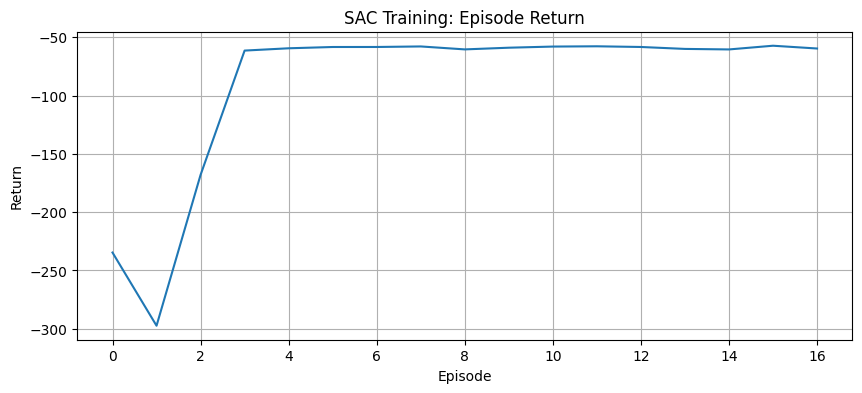

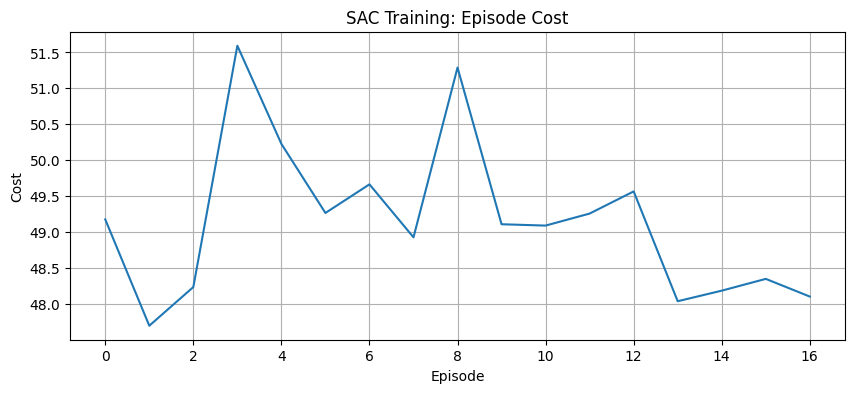

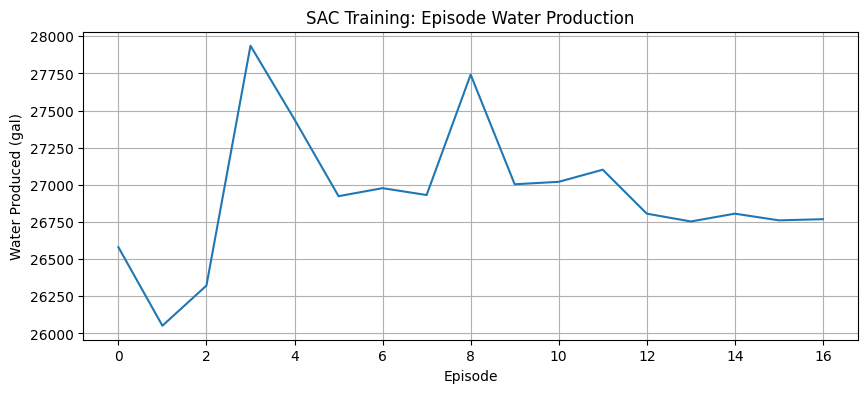

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(train_logs["episode"], train_logs["episode_return"])
plt.title("SAC Training: Episode Return")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(train_logs["episode"], train_logs["episode_cost"])
plt.title("SAC Training: Episode Cost")
plt.xlabel("Episode")
plt.ylabel("Cost")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(train_logs["episode"], train_logs["episode_water"])
plt.title("SAC Training: Episode Water Production")
plt.xlabel("Episode")
plt.ylabel("Water Produced (gal)")
plt.grid(True)
plt.show()

In [ ]:
def run_policy_episode(env, agent=None, deterministic=True, tariff_name=None):
    state = env.reset(tariff_name=tariff_name)

    done = False
    rows = []

    while not done:
        if agent is None:
            raw_action = np.zeros(env.action_dim, dtype=np.float32)
        else:
            raw_action = agent.select_action(state, deterministic=deterministic)

        next_state, reward, done, info = env.step(raw_action)

        rows.append({
            "hour": env.t,
            "reward": reward,
            **info
        })

        state = next_state

    return pd.DataFrame(rows)


eval_df = run_policy_episode(env, agent, deterministic=True)
eval_df.head()

,hour,reward,tariff_name,q_perm_gpm,q_conc_gpm,q_recirc_gpm,power_w,power_kw,price,step_cost,water_gal,cumulative_gal,target_total_gal,backlog,smooth_penalty,violation_penalty,recovery
0,1,-0.327619,simple_tou,2.166766,1.449985,1.818801,1335.721683,1.335722,0.1,0.133572,130.005951,130.005951,26806.212462,0.001103,0.837928,0.000000e+00,0.599092
1,2,-0.319196,simple_tou,2.471412,1.792813,1.731386,1450.793135,1.450793,0.1,0.145079,148.284725,278.290677,26806.212462,0.001523,0.217982,0.000000e+00,0.579569
2,3,-0.319340,simple_tou,2.614500,1.931852,1.774877,1528.139482,1.528139,0.1,0.152814,156.870010,435.160687,26806.212462,0.001624,0.041697,4.814825e-31,0.575076
3,4,-0.314897,simple_tou,2.682498,1.997925,1.795545,1567.804125,1.567804,0.1,0.156780,160.949859,596.110546,26806.212462,0.001572,0.009416,3.562970e-32,0.573131
4,5,-0.303690,simple_tou,2.714919,2.029429,1.805399,1587.397633,1.587398,0.1,0.158740,162.895151,759.005697,26806.212462,0.001447,0.002141,7.004607e-31,0.572243


In [ ]:
baseline_raw = 2.0 * (
    data.baseline_action - data.feasible_region.low
) / (
    data.feasible_region.high - data.feasible_region.low
) - 1.0

baseline_raw = np.clip(baseline_raw, -1.0, 1.0).astype(np.float32)

def run_fixed_action_episode(env, raw_action):
    state = env.reset()
    done = False
    rows = []

    while not done:
        next_state, reward, done, info = env.step(raw_action)

        rows.append({
            "hour": env.t,
            "reward": reward,
            **info
        })

        state = next_state

    return pd.DataFrame(rows)


baseline_df = run_fixed_action_episode(env, baseline_raw)

print("RL cost:", eval_df["step_cost"].sum())
print("Baseline cost:", baseline_df["step_cost"].sum())

print("RL water:", eval_df["water_gal"].sum())
print("Baseline water:", baseline_df["water_gal"].sum())

print("RL final backlog:", eval_df["backlog"].iloc[-1])
print("Baseline final backlog:", baseline_df["backlog"].iloc[-1])

RL cost: 47.26843066015539
Baseline cost: 43.955231185851936
RL water: 26561.24247776255
Baseline water: 23919.92755623854
RL final backlog: 0.009138552644167337
Baseline final backlog: 0.10767223864379548


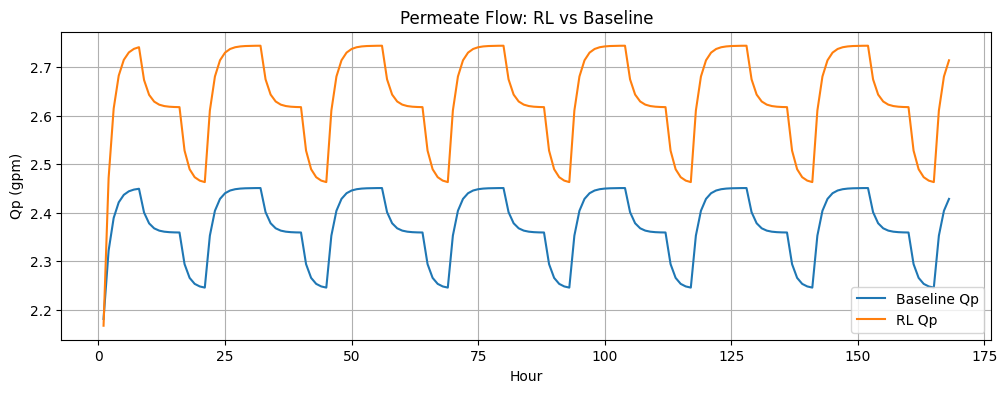

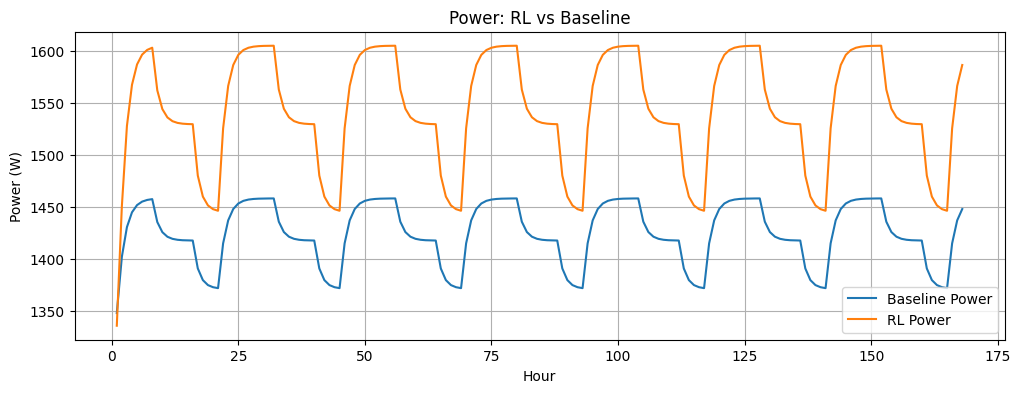

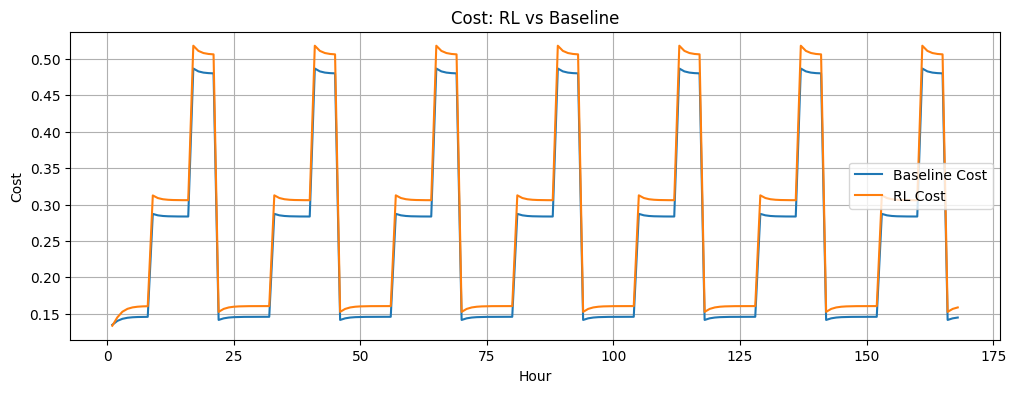

In [ ]:
    plt.figure(figsize=(12, 4))
    plt.plot(baseline_df["hour"], baseline_df["q_perm_gpm"], label="Baseline Qp")
    plt.plot(eval_df["hour"], eval_df["q_perm_gpm"], label="RL Qp")
    plt.title("Permeate Flow: RL vs Baseline")
    plt.xlabel("Hour")
    plt.ylabel("Qp (gpm)")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(baseline_df["hour"], baseline_df["power_w"], label="Baseline Power")
    plt.plot(eval_df["hour"], eval_df["power_w"], label="RL Power")
    plt.title("Power: RL vs Baseline")
    plt.xlabel("Hour")
    plt.ylabel("Power (W)")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(baseline_df["hour"], baseline_df["step_cost"], label="Baseline Cost")
    plt.plot(eval_df["hour"], eval_df["step_cost"], label="RL Cost")
    plt.title("Cost: RL vs Baseline")
    plt.xlabel("Hour")
    plt.ylabel("Cost")
    plt.grid(True)
    plt.legend()
    plt.show()

In [ ]:
import os

os.makedirs("../models", exist_ok=True)
os.makedirs("../models/rl_outputs", exist_ok=True)

torch.save(
    {
        "policy": agent.policy.state_dict(),
        "q1": agent.q1.state_dict(),
        "q2": agent.q2.state_dict(),
        "q1_target": agent.q1_target.state_dict(),
        "q2_target": agent.q2_target.state_dict(),
        "log_alpha": agent.log_alpha.detach().cpu().item(),
    },
    "../models/rl_outputs/sac_ro_agent.pt"
)

train_logs.to_csv("../models/rl_outputs/train_logs.csv", index=False)
eval_df.to_csv("../models/rl_outputs/eval_policy.csv", index=False)
baseline_df.to_csv("../models/rl_outputs/baseline_policy.csv", index=False)

print("Saved RL outputs to ../models/rl_outputs/")

Saved RL outputs to ../models/rl_outputs/
